# projetc 1: Customer_Churn_Prediction

## Step 1: Import Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load Dataset

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Basic Information

In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

## Step 4: Data Cleaning

### Check Missing Values

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Check Duplicate Rows

In [10]:
df.duplicated().sum()

np.int64(0)

### Remove Unnecessary Columns

These columns don't help in prediction.

In [11]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 5: Exploratory Data Analysis (EDA)
Target Variable Distribution

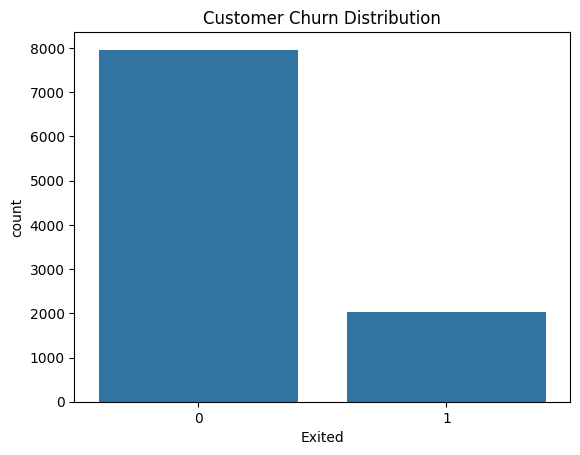

In [12]:
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

### Gender Distribution

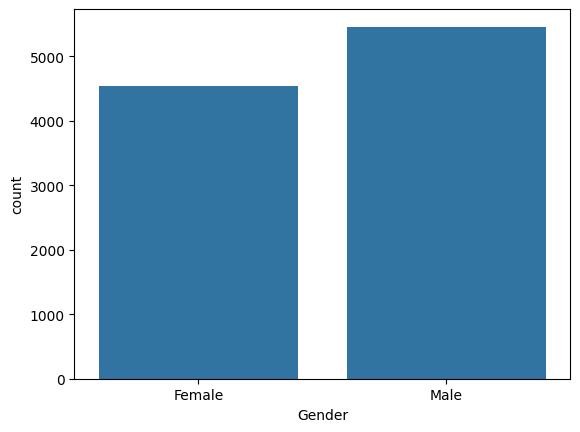

In [13]:
sns.countplot(x="Gender", data=df)
plt.show()

### Geography Distribution

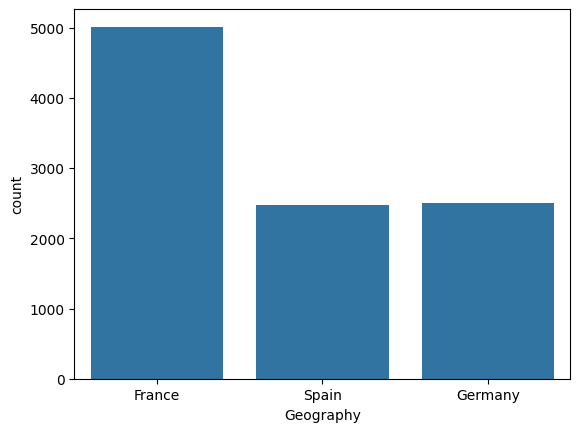

In [14]:
sns.countplot(x="Geography", data=df)
plt.show()

### Age Distribution

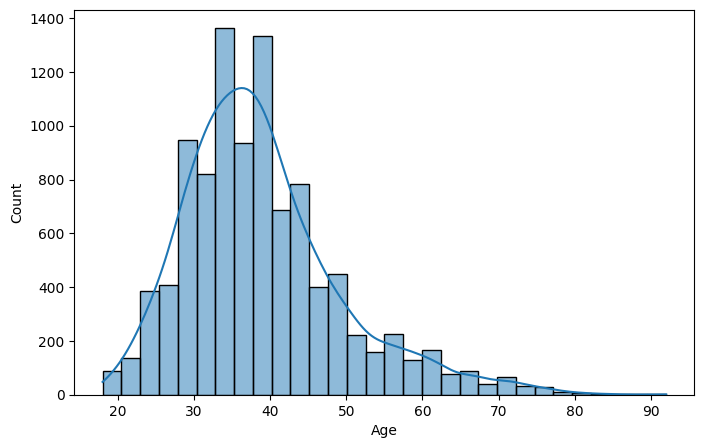

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.show()

### Correlation Heatmap

First convert categorical columns to numeric.

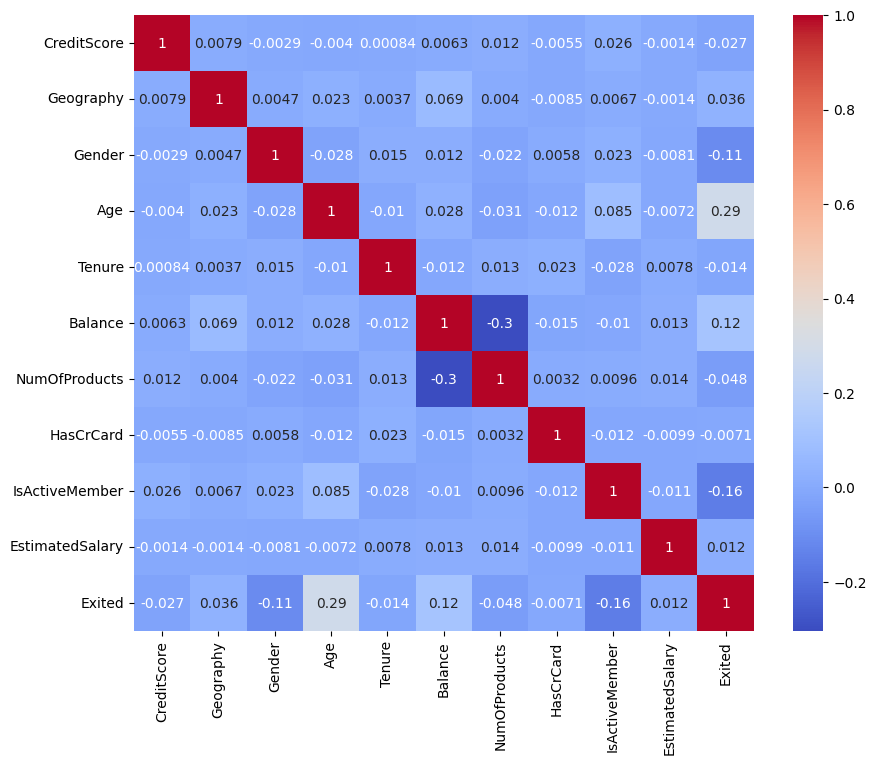

In [16]:
temp = df.copy()

temp["Gender"] = LabelEncoder().fit_transform(temp["Gender"])
temp["Geography"] = LabelEncoder().fit_transform(temp["Geography"])
## gender and geography are categorical columns 
plt.figure(figsize=(10,8))
sns.heatmap(temp.corr(), annot=True, cmap="coolwarm")
plt.show()

## Step 6: Feature Engineering

In [ ]:
## Convert Gender and geography

In [17]:
le_gender = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])

In [18]:
le_geo = LabelEncoder()

df["Geography"] = le_geo.fit_transform(df["Geography"])

In [19]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

## Step 7: Split Dataset

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,## 20%
    random_state=42
)

## Step 8: Model Training

## Logistic Regression

In [21]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Decision Tree

In [26]:
dt = DecisionTreeClassifier(random_state=42)
## random_state=42 ensures your model splits and builds the exact same way every time you run the code so your results are reproducible
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Random Forest

In [25]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# Step 9: Accuracy Comparison

In [27]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression :", lr_acc)
print("Decision Tree       :", dt_acc)
print("Random Forest       :", rf_acc)

Logistic Regression : 0.799
Decision Tree       : 0.782
Random Forest       : 0.8645


## bets accuracy is random forest 86.45 %

### Compare Models

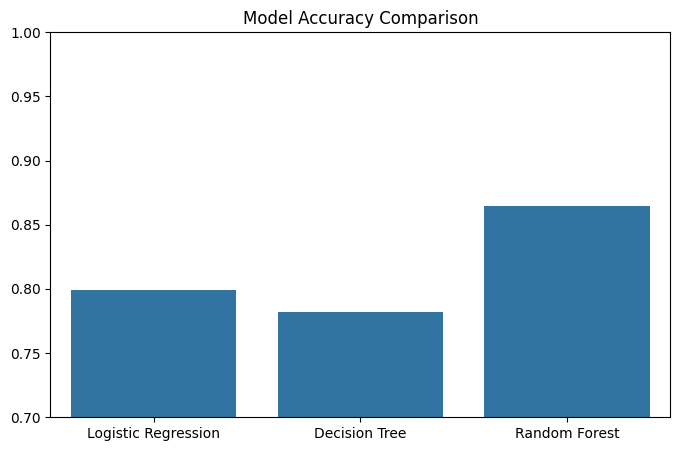

In [29]:
models = ["Logistic Regression","Decision Tree","Random Forest"]

accuracy = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=accuracy)

plt.ylim(0.7,1)

plt.title("Model Accuracy Comparison")

plt.show()

# Step 10: Confusion Matrix

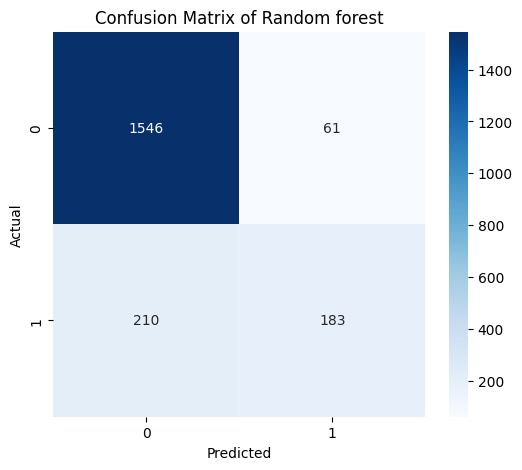

In [33]:
## random forest 
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix of Random forest")

plt.show()

# Step 11: Classification Report

In [34]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



# Step 12: ROC Curve

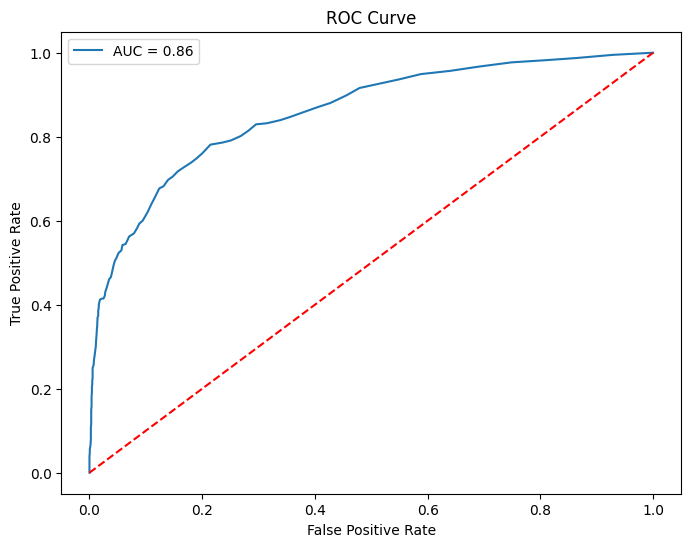

In [35]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="AUC = %0.2f"%roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Step 13: Feature Importance

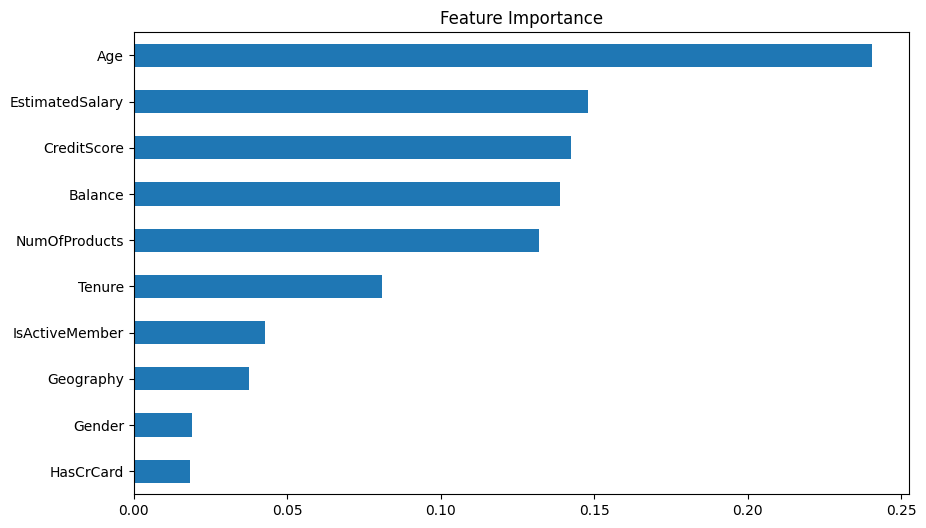

In [37]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Feature Importance")

plt.show()